# Qwen Vision 도면 View BBox 분할

기존 전체 페이지 1회 추론은 `main_view` 상단에 박스가 몰리는 문제가 있었습니다. 이 노트북은 먼저 `preprocess_out/<도면명>/manifest.json`의 레이아웃 prior를 사용하고, manifest가 없을 때만 Together Vision의 다중 영역 추론으로 내려가도록 수정한 버전입니다.

## 목적
- 도면 한 페이지에서 `main_view`, `sub_view`, `table_view`, `text_notes`에 해당하는 bbox를 안정적으로 분리합니다.
- bbox 결과를 바탕으로 각 view 별 치수 OCR JSON까지 함께 내보냅니다.

## 처리 순서
1. PDF 1페이지를 고해상도 이미지로 렌더링합니다.
2. `manifest.json`이 있으면 그 안의 레이아웃 정보를 우선 사용합니다.
3. 단, 잘린 `sub_view`는 여백과 connected component를 이용해 bbox를 보정합니다.
4. layout prior가 없으면 Together Vision에 전체 페이지 + 부분 crop을 여러 번 질의해 view를 찾습니다.
5. 최종 bbox를 시각화하고, bbox JSON / dimension JSON / 비교 JSON을 저장합니다.

## 이 노트북에서 특히 볼 부분
- `normalize_box_to_image`: 모델이 비율 좌표, 1000 기준 좌표, 픽셀 좌표 중 어떤 형식으로 답해도 한 형식으로 맞춥니다.
- `project_layout_bbox_to_target`: 전처리 단계의 좌표계를 현재 렌더링 이미지 좌표계로 옮깁니다.
- `extract_views_with_multi_pass`: 전체 페이지 추론만으로 놓치기 쉬운 하단 표, 우측 서브뷰를 crop 기반 추론으로 보완합니다.
- `export_view_bboxes_and_dimensions`: bbox 결과를 치수 추출 단계와 동일한 view 기준으로 묶어 JSON으로 저장합니다.

## 출력물
- `*_segmented.jpg`: 최종 bbox 시각화 이미지
- `bbox_exports/*_view_bboxes.json`: view bbox 결과
- `bbox_exports/*_view_dimensions.json`: view 별 치수 추출 결과
- `bbox_exports/*comparison*.json`: 도면 간 치수 비교 결과

In [16]:
import os
import html
import importlib
import sys
import json
import base64
from pathlib import Path

import cv2
import fitz
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np
from IPython.display import HTML, Markdown, display
from dotenv import load_dotenv
from openai import OpenAI, APIStatusError, AuthenticationError, BadRequestError

HELPER_DIR_CANDIDATES = [Path('.'), Path('Qwen-25-VL')]
# 노트북을 어느 위치에서 실행하더라도 helper 모듈을 찾을 수 있게 경로를 보정합니다.
for helper_dir in HELPER_DIR_CANDIDATES:
    helper_dir_resolved = helper_dir.resolve()
    if helper_dir.exists() and str(helper_dir_resolved) not in sys.path:
        sys.path.insert(0, str(helper_dir_resolved))

import bbox_dimension_utils as bdu

bdu = importlib.reload(bdu)
build_bbox_payload = bdu.build_bbox_payload
build_dimension_payload = bdu.build_dimension_payload
compare_dimension_json_files = bdu.compare_dimension_json_files
extract_dimensions_for_views = bdu.extract_dimensions_for_views
save_bbox_payload = bdu.save_bbox_payload
save_comparison_payload = bdu.save_comparison_payload
save_dimension_payload = bdu.save_dimension_payload

# ==========================================
# 1. 환경 설정 및 API 키 로드
# ==========================================
ENV_CANDIDATES = [Path('.env'), Path('..') / '.env']
for env_candidate in ENV_CANDIDATES:
    if env_candidate.exists():
        load_dotenv(env_candidate, override=False)
        break
API_KEY = os.getenv("TOGETHER_API_KEY")
DEFAULT_MODEL_NAME = "Qwen/Qwen3-VL-8B-Instruct"
DEDICATED_ONLY_MODEL_NAME = "Qwen/Qwen2.5-VL-72B-Instruct"
MODEL_NAME = os.getenv("TOGETHER_VISION_MODEL", DEFAULT_MODEL_NAME)
USE_LAYOUT_PRIOR = True
EXPORT_DIR = Path('bbox_exports')

if not API_KEY:
    raise ValueError("TOGETHER_API_KEY가 설정되지 않았습니다. .env 파일을 확인해주세요.")

client = OpenAI(api_key=API_KEY, base_url="https://api.together.xyz/v1")
print(f"Together Vision model: {MODEL_NAME}")
print(f"Layout prior enabled: {USE_LAYOUT_PRIOR}")
print(f"BBox export dir: {EXPORT_DIR.resolve()}")


def configure_matplotlib_korean_font():
    preferred_font_paths = [
        Path('/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc'),
        Path('/usr/share/fonts/opentype/noto/NotoSansCJK-Medium.ttc'),
        Path('/usr/share/fonts/opentype/noto/NotoSerifCJK-Regular.ttc'),
    ]
    preferred_fonts = [
        'Noto Sans CJK KR',
        'Noto Serif CJK KR',
        'Noto Sans CJK JP',
        'Noto Serif CJK JP',
        'NanumGothic',
        'Malgun Gothic',
        'AppleGothic',
    ]

    for font_path in preferred_font_paths:
        if font_path.exists():
            try:
                fm.fontManager.addfont(str(font_path))
            except Exception:
                pass

    available_names = {font.name for font in fm.fontManager.ttflist}
    for font_name in preferred_fonts:
        if font_name in available_names:
            plt.rcParams['font.family'] = font_name
            plt.rcParams['axes.unicode_minus'] = False
            print(f'Matplotlib font set to: {font_name}')
            return font_name

    for font_path in preferred_font_paths:
        if font_path.exists():
            try:
                font_name = fm.FontProperties(fname=str(font_path)).get_name()
                plt.rcParams['font.family'] = font_name
                plt.rcParams['axes.unicode_minus'] = False
                print(f'Matplotlib font set via path: {font_name} ({font_path})')
                return font_name
            except Exception:
                pass

    plt.rcParams['axes.unicode_minus'] = False
    print('Matplotlib Korean font not found. Titles may render incorrectly.')
    return None


PLOT_FONT_NAME = configure_matplotlib_korean_font()


def resolve_existing_path(*candidates):
    for candidate in candidates:
        path = Path(candidate)
        if path.exists():
            return str(path)
    return str(Path(candidates[0]))


def raise_together_api_error(exc, model_name):
    status_code = getattr(exc, "status_code", None)
    body = getattr(exc, "body", None)
    error_payload = body.get("error", {}) if isinstance(body, dict) else {}
    message = error_payload.get("message") or str(exc)

    if status_code == 400 and "non-serverless model" in message:
        raise RuntimeError(
            "Together API 호출 실패: "
            f"`{model_name}` 는 현재 serverless로 바로 사용할 수 없습니다. "
            f"기본값은 `{DEFAULT_MODEL_NAME}` 입니다. "
            f"`TOGETHER_VISION_MODEL`을 다른 serverless vision 모델로 바꾸거나, "
            f"`{DEDICATED_ONLY_MODEL_NAME}`를 쓰려면 dedicated endpoint를 생성하세요.\n"
            f"원문: {message}"
        ) from exc

    if status_code == 401:
        raise RuntimeError(
            "Together API 인증 실패: `TOGETHER_API_KEY`가 유효하지 않습니다. 현재 .env 값을 확인한 뒤 다시 시도하세요."
        ) from exc

    if status_code == 402:
        raise RuntimeError(
            "Together API 크레딧 부족: billing에서 크레딧을 충전한 뒤 다시 시도하세요."
        ) from exc

    raise RuntimeError(
        f"Together API 호출 실패: status_code={status_code}, model={model_name}. 원문: {message}"
    ) from exc


Together Vision model: Qwen/Qwen3-VL-8B-Instruct
Layout prior enabled: True
BBox export dir: /home/jhkim/projects/Kardinex/prototype/Qwen-25-VL/bbox_exports
Matplotlib font set to: Noto Sans CJK JP


In [17]:
# ==========================================
# 2. 공통 유틸리티
# ==========================================
LABEL_MAP = {
    "main_drawing": "main_view",
    "sub_view": "sub_view",
    "table_small": "table_view",
    "table_large": "table_view",
}


def convert_pdf_to_image(pdf_path, dpi=200):
    print(f"[{pdf_path}] PDF를 고해상도 이미지로 변환 중...")
    doc = fitz.open(pdf_path)
    page = doc.load_page(0)
    pix = page.get_pixmap(dpi=dpi)

    pdf_path = Path(pdf_path)
    img_path = pdf_path.with_suffix(".jpg")
    pix.save(str(img_path))
    print(f" -> '{img_path}' 저장 완료. size={pix.width}x{pix.height}")
    return str(img_path)


def encode_image(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode("utf-8")


def strip_fenced_json(text):
    text = (text or "").strip()
    if text.startswith("```json"):
        return text[7:-3].strip()
    if text.startswith("```"):
        return text[3:-3].strip()
    return text


def extract_json_array_text(text):
    text = strip_fenced_json(text)
    start = text.find("[")
    end = text.rfind("]")
    if start >= 0 and end > start:
        return text[start:end + 1]
    return text


def clamp_box(box, width, height):
    x1, y1, x2, y2 = [int(round(float(v))) for v in box[:4]]
    x1 = max(0, min(x1, width - 1))
    y1 = max(0, min(y1, height - 1))
    x2 = max(0, min(x2, width - 1))
    y2 = max(0, min(y2, height - 1))
    if x2 <= x1 or y2 <= y1:
        return None
    return [x1, y1, x2, y2]


def normalize_box_to_image(box, width, height):
    if not isinstance(box, (list, tuple)) or len(box) < 4:
        return None
    coords = [float(v) for v in box[:4]]
    max_coord = max(coords)
    min_coord = min(coords)

    # 모델 응답이 0~1 비율 좌표인 경우 현재 이미지 크기에 맞춰 픽셀로 환산합니다.
    if min_coord >= 0 and max_coord <= 1.5:
        scaled = [coords[0] * width, coords[1] * height, coords[2] * width, coords[3] * height]
        return clamp_box(scaled, width, height)

    # 일부 응답은 1000 기준 정규화 좌표로 들어오므로 같은 픽셀 좌표계로 다시 맞춥니다.
    if min_coord >= 0 and max_coord <= 1001 and (width > 1200 or height > 1200):
        scaled = [
            coords[0] * width / 1000.0,
            coords[1] * height / 1000.0,
            coords[2] * width / 1000.0,
            coords[3] * height / 1000.0,
        ]
        return clamp_box(scaled, width, height)

    return clamp_box(coords, width, height)


def translate_box_from_crop(local_box, crop_bbox, full_width, full_height):
    crop_x1, crop_y1, crop_x2, crop_y2 = crop_bbox
    crop_width = crop_x2 - crop_x1
    crop_height = crop_y2 - crop_y1
    # crop 내부 좌표를 먼저 정규화한 뒤, 원본 전체 이미지 기준 전역 좌표로 다시 옮깁니다.
    normalized = normalize_box_to_image(local_box, crop_width, crop_height)
    if normalized is None:
        return None
    x1, y1, x2, y2 = normalized
    return clamp_box([x1 + crop_x1, y1 + crop_y1, x2 + crop_x1, y2 + crop_y1], full_width, full_height)


def load_image_bgr(image_path):
    image = cv2.imread(image_path)
    if image is None:
        raise RuntimeError(f"이미지를 불러올 수 없습니다: {image_path}")
    return image


def load_image_gray(image_path):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise RuntimeError(f"이미지를 불러올 수 없습니다: {image_path}")
    return image


def crop_image(image, bbox):
    x1, y1, x2, y2 = bbox
    return image[y1:y2, x1:x2].copy()


def measure_content_margins(gray_image, threshold=220):
    # 밝은 배경을 제외한 실제 도형/텍스트가 bbox 가장자리에서 얼마나 떨어져 있는지 봅니다.
    mask = gray_image < threshold
    if not mask.any():
        return None
    rows = np.where(mask.any(axis=1))[0]
    cols = np.where(mask.any(axis=0))[0]
    height, width = gray_image.shape[:2]
    margins = {
        "left": int(cols.min()),
        "top": int(rows.min()),
        "right": int(width - 1 - cols.max()),
        "bottom": int(height - 1 - rows.max()),
    }
    return margins


In [18]:
# ==========================================
# 3. Layout prior + Vision 추출
# ==========================================
def find_manifest_path(pdf_path):
    stem = Path(pdf_path).stem
    candidates = [
        Path("../preprocess_out") / stem / "manifest.json",
        Path("preprocess_out") / stem / "manifest.json",
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    return None


def load_layout_prior_context(pdf_path):
    manifest_path = find_manifest_path(pdf_path)
    if not manifest_path:
        return None

    # 전처리 단계에서 저장한 render / frame-removed / normalized 좌표계를 함께 읽어 둡니다.
    work_dir = manifest_path.parent
    manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
    crop_bbox = manifest.get("crop_bbox_after_frame_removal")

    render_path = work_dir / "00_render.png"
    normalized_path = work_dir / "03_normalized.png"
    frame_removed_path = work_dir / "02_frame_removed.png"

    render_size = None
    normalized_size = None
    frame_removed_size = None

    if render_path.exists():
        render_img = load_image_bgr(str(render_path))
        render_size = (render_img.shape[1], render_img.shape[0])
    if normalized_path.exists():
        normalized_img = load_image_bgr(str(normalized_path))
        normalized_size = (normalized_img.shape[1], normalized_img.shape[0])
    if frame_removed_path.exists():
        frame_removed_img = load_image_bgr(str(frame_removed_path))
        frame_removed_size = (frame_removed_img.shape[1], frame_removed_img.shape[0])
    elif crop_bbox and len(crop_bbox) == 4:
        frame_removed_size = (crop_bbox[2] - crop_bbox[0], crop_bbox[3] - crop_bbox[1])

    if not render_size or not normalized_size or not frame_removed_size or not crop_bbox:
        return None

    return {
        "manifest_path": manifest_path,
        "work_dir": work_dir,
        "manifest": manifest,
        "crop_bbox": crop_bbox,
        "render_size": render_size,
        "normalized_size": normalized_size,
        "frame_removed_size": frame_removed_size,
    }


def binarize_for_region_refine(gray):
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    bw = cv2.adaptiveThreshold(
        blur,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        51,
        11,
    )
    bw = cv2.morphologyEx(bw, cv2.MORPH_OPEN, np.ones((2, 2), np.uint8), iterations=1)
    return bw


def find_connected_component_extension(region_bbox, context):
    normalized_path = context['work_dir'] / '03_normalized.png'
    if not normalized_path.exists():
        return None

    gray = load_image_gray(str(normalized_path))
    norm_w, norm_h = context['normalized_size']
    x1, y1, x2, y2 = [int(v) for v in region_bbox[:4]]
    # 초기 bbox 주변을 조금 더 넓게 탐색해서 실제 view에 붙어 있는 큰 연결요소를 찾습니다.
    search_bbox = clamp_box(
        [
            x1 - 24,
            y1 - 24,
            x2 + max(100, int(round((x2 - x1) * 0.28))),
            y2 + max(120, int(round((y2 - y1) * 0.45))),
        ],
        norm_w,
        norm_h,
    )
    if search_bbox is None:
        return None

    sx1, sy1, sx2, sy2 = search_bbox
    bw = binarize_for_region_refine(gray[sy1:sy2, sx1:sx2])
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(bw, connectivity=8)

    best_bbox = None
    best_area = 0
    for comp_idx in range(1, num_labels):
        cx, cy, cw, ch, area = stats[comp_idx]
        if area < 40:
            continue
        gx1, gy1 = cx + sx1, cy + sy1
        gx2, gy2 = gx1 + cw, gy1 + ch
        intersects = not (gx2 < x1 or gy2 < y1 or gx1 > x2 or gy1 > y2)
        if not intersects:
            continue
        # 기존 bbox와 맞닿아 있는 후보 중 가장 큰 덩어리를 view 본체로 간주합니다.
        if area > best_area:
            best_area = area
            best_bbox = [int(gx1), int(gy1), int(gx2), int(gy2)]

    if best_bbox is None:
        return None

    refined = clamp_box(
        [
            min(x1, best_bbox[0]) - 8,
            min(y1, best_bbox[1]) - 8,
            max(x2, best_bbox[2]) + 8,
            max(y2, best_bbox[3]) + 8,
        ],
        norm_w,
        norm_h,
    )
    return refined


def refine_layout_region_bbox(region, context):
    bbox = list(region.get("bbox") or [])
    if region.get("label") != "sub_view" or len(bbox) < 4:
        return bbox

    crop_name = region.get("file")
    if not crop_name:
        return bbox

    crop_path = context["work_dir"] / crop_name
    if not crop_path.exists():
        return bbox

    gray = load_image_gray(str(crop_path))
    margins = measure_content_margins(gray)
    if not margins:
        return bbox

    x1, y1, x2, y2 = [int(v) for v in bbox[:4]]
    crop_h, crop_w = gray.shape[:2]

    # 비대칭으로 잘린 sub_view만 확장한다.
    expanded = False

    # 오른쪽/아래쪽이 crop 경계에 딱 붙어 있으면 잘렸을 가능성이 높아 해당 방향만 늘립니다.
    if margins["right"] == 0 and margins["left"] >= 6:
        expand_right = max(int(round(margins["left"] * 1.6)), int(round(crop_w * 0.04)))
        x2 += expand_right
        expanded = True
    if margins["bottom"] == 0 and margins["top"] >= 6:
        expand_bottom = max(int(round(margins["top"] * 1.6)), int(round(crop_h * 0.05)))
        y2 += expand_bottom
        expanded = True

    norm_w, norm_h = context["normalized_size"]
    refined = clamp_box([x1, y1, x2, y2], norm_w, norm_h) or bbox
    if expanded and refined != bbox:
        print(f"layout prior sub_view 1차 확장: {crop_name} margins={margins} -> {refined}")

    component_refined = None
    if margins['right'] == 0 or margins['bottom'] == 0:
        # 여백 기반 확장만으로 부족한 경우 실제 connected component 외곽까지 다시 확장합니다.
        component_refined = find_connected_component_extension(refined, context)
    if component_refined is not None and component_refined != refined:
        print(f"layout prior sub_view CC 확장: {crop_name} -> {component_refined}")
        refined = component_refined
    return refined


def project_layout_bbox_to_target(box, context, target_width, target_height):
    normalized_width, normalized_height = context["normalized_size"]
    frame_removed_width, frame_removed_height = context["frame_removed_size"]
    render_width, render_height = context["render_size"]
    crop_x1, crop_y1, _, _ = context["crop_bbox"]

    coords = [float(v) for v in box[:4]]
    # normalized -> frame_removed -> render -> 현재 target image 순서로 bbox를 단계별 변환합니다.
    frame_removed_box = [
        coords[0] * frame_removed_width / normalized_width,
        coords[1] * frame_removed_height / normalized_height,
        coords[2] * frame_removed_width / normalized_width,
        coords[3] * frame_removed_height / normalized_height,
    ]
    render_box = [
        frame_removed_box[0] + crop_x1,
        frame_removed_box[1] + crop_y1,
        frame_removed_box[2] + crop_x1,
        frame_removed_box[3] + crop_y1,
    ]
    target_box = [
        render_box[0] * target_width / render_width,
        render_box[1] * target_height / render_height,
        render_box[2] * target_width / render_width,
        render_box[3] * target_height / render_height,
    ]
    return clamp_box(target_box, target_width, target_height)


def load_layout_prior_views(pdf_path, image_shape):
    context = load_layout_prior_context(pdf_path)
    if not context:
        return []

    # manifest를 신뢰 가능한 1차 bbox 소스로 사용하고, 현재 페이지 이미지 크기에 맞춰 재투영합니다.
    height, width = image_shape[:2]
    views = []
    for region in context["manifest"].get("regions", []):
        mapped_type = LABEL_MAP.get(region.get("label"))
        bbox = refine_layout_region_bbox(region, context)
        if not mapped_type or not bbox:
            continue
        projected = project_layout_bbox_to_target(bbox, context, width, height)
        if projected is None:
            continue
        views.append(
            {
                "view_type": mapped_type,
                "box": projected,
                "source": "layout_prior",
                "score": region.get("score"),
                "layout_label": region.get("label"),
            }
        )
    if views:
        render_width, render_height = context["render_size"]
        normalized_width, normalized_height = context["normalized_size"]
        print(
            f"[{pdf_path}] layout prior 적용: {context['manifest_path']} -> {len(views)} regions | "
            f"normalized={normalized_width}x{normalized_height}, render={render_width}x{render_height}, target={width}x{height}"
        )
    return views


def build_view_prompt(image_width, image_height, allowed_types=None, focus_hint=None):
    allowed_types = allowed_types or ["main_view", "sub_view", "detail_view", "table_view", "text_notes"]
    allowed_text = ", ".join(allowed_types)
    focus_line = f"추가 힌트: {focus_hint}" if focus_hint else "추가 힌트 없음"
    # 프롬프트에는 허용 라벨, 좌표계 기준, 놓치기 쉬운 view 힌트를 함께 넣습니다.
    return f"""
너는 기계 엔지니어링 도면 분석 전문가야. 주어진 이미지에서 독립된 view 영역만 찾아라.

[중요]
- 좌표는 반드시 이 이미지 기준의 절대 픽셀 좌표로 출력한다.
- 이미지 크기: width={image_width}, height={image_height}
- 허용되는 view_type: {allowed_text}
- 각 bbox는 해당 view의 형상, 치수선, 보조선, 라벨을 모두 포함해야 한다.
- 서로 다른 view는 가능하면 겹치지 않게 나눈다.
- 존재하지 않는 타입은 억지로 만들지 않는다.
- table 영역은 표 전체를 감싸는 하나의 큰 bbox로 잡는다.
- 우측 하단 표제란/리비전표도 table_view 또는 text_notes로 분리할 수 있다.
- main_view만 반복해서 내지 말고, 페이지 전체에서 분리된 모든 sub_view와 table_view를 포함한다.
- {focus_line}

[출력 형식]
JSON 배열만 출력한다.
[{{\"view_type\": \"main_view\", \"box\": [x1, y1, x2, y2]}}]
"""


def request_views_from_model(image_bgr, allowed_types=None, focus_hint=None):
    height, width = image_bgr.shape[:2]
    ok, encoded = cv2.imencode(".jpg", image_bgr)
    if not ok:
        raise RuntimeError("이미지 인코딩에 실패했습니다.")
    base64_img = base64.b64encode(encoded.tobytes()).decode("utf-8")
    prompt_text = build_view_prompt(width, height, allowed_types=allowed_types, focus_hint=focus_hint)

    try:
        response = client.chat.completions.create(
            model=MODEL_NAME,
            messages=[
                {
                    "role": "user",
                    "content": [
                        {"type": "text", "text": prompt_text},
                        {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{base64_img}"}},
                    ],
                }
            ],
            temperature=0.1,
        )
    except (BadRequestError, AuthenticationError, APIStatusError) as exc:
        raise_together_api_error(exc, MODEL_NAME)

    result_text = extract_json_array_text(response.choices[0].message.content or "")
    try:
        items = json.loads(result_text)
    except json.JSONDecodeError:
        print("JSON 파싱 에러! 모델 원본 출력:\n", result_text)
        return []

    views = []
    for item in items if isinstance(items, list) else []:
        view_type = item.get("view_type")
        # 모델이 어떤 좌표 형식으로 답하더라도 후속 단계는 항상 픽셀 bbox 하나만 다루게 합니다.
        box = normalize_box_to_image(item.get("box"), width, height)
        if not view_type or box is None:
            continue
        views.append({"view_type": view_type, "box": box, "source": "vision_full_or_crop"})
    return views


def merge_near_duplicate_views(views, iou_threshold=0.6):
    def iou(box_a, box_b):
        ax1, ay1, ax2, ay2 = box_a
        bx1, by1, bx2, by2 = box_b
        inter_x1 = max(ax1, bx1)
        inter_y1 = max(ay1, by1)
        inter_x2 = min(ax2, bx2)
        inter_y2 = min(ay2, by2)
        if inter_x2 <= inter_x1 or inter_y2 <= inter_y1:
            return 0.0
        inter = (inter_x2 - inter_x1) * (inter_y2 - inter_y1)
        area_a = (ax2 - ax1) * (ay2 - ay1)
        area_b = (bx2 - bx1) * (by2 - by1)
        union = area_a + area_b - inter
        return inter / union if union else 0.0

    merged = []
    # 전체 페이지 추론과 crop 추론 결과가 겹치므로, 같은 타입의 거의 같은 박스는 하나만 남깁니다.
    for view in views:
        keep = True
        for existing in merged:
            if view["view_type"] == existing["view_type"] and iou(view["box"], existing["box"]) >= iou_threshold:
                keep = False
                break
        if keep:
            merged.append(view)
    return merged


def extract_views_with_multi_pass(image_path):
    image = load_image_bgr(image_path)
    full_height, full_width = image.shape[:2]
    views = []

    # 1차: 전체 페이지에서 큰 구조를 먼저 잡습니다.
    full_page_views = request_views_from_model(
        image,
        allowed_types=["main_view", "sub_view", "detail_view", "table_view", "text_notes"],
        focus_hint="전체 페이지에서 분리된 모든 view를 잡아라. 특히 하단 table과 우측 sub_view를 누락하지 마라.",
    )
    views.extend(full_page_views)

    crop_specs = [
        # 2차: 누락되기 쉬운 영역만 따로 crop 해서 세밀하게 다시 찾습니다.
        {
            "name": "drawing_area",
            "bbox": [0, 0, full_width, int(full_height * 0.82)],
            "allowed_types": ["main_view", "sub_view", "detail_view", "text_notes"],
            "focus_hint": "상단 및 중앙의 main/sub/detail view만 본다. 하단 table은 무시한다.",
        },
        {
            "name": "bottom_tables",
            "bbox": [0, int(full_height * 0.68), full_width, full_height],
            "allowed_types": ["table_view", "text_notes", "sub_view"],
            "focus_hint": "하단 표 영역과 하단 sub_view를 우선적으로 찾는다.",
        },
        {
            "name": "right_panel",
            "bbox": [int(full_width * 0.55), 0, full_width, full_height],
            "allowed_types": ["sub_view", "detail_view", "table_view", "text_notes"],
            "focus_hint": "우측 패널의 sub_view, detail_view, table_view를 찾는다.",
        },
    ]

    for spec in crop_specs:
        crop = crop_image(image, spec["bbox"])
        local_views = request_views_from_model(
            crop,
            allowed_types=spec["allowed_types"],
            focus_hint=spec["focus_hint"],
        )
        for item in local_views:
            # crop 기준 bbox를 원본 페이지 기준 bbox로 되돌려 합칩니다.
            global_box = translate_box_from_crop(item["box"], spec["bbox"], full_width, full_height)
            if global_box is None:
                continue
            views.append(
                {
                    "view_type": item["view_type"],
                    "box": global_box,
                    "source": f"vision_crop:{spec['name']}",
                }
            )

    return merge_near_duplicate_views(views)


def extract_views(image_path, pdf_path):
    image = load_image_bgr(image_path)
    if USE_LAYOUT_PRIOR:
        # 우선순위 1: 전처리 manifest 기반 bbox
        layout_views = load_layout_prior_views(pdf_path, image.shape)
        if layout_views:
            return layout_views
    # 우선순위 2: Vision 다중 패스 추론 fallback
    print(f"[{image_path}] layout prior 없음. Together Vision 다중 영역 추론으로 진행합니다...")
    return extract_views_with_multi_pass(image_path)


In [19]:
# ==========================================
# 4. 시각화
# ==========================================
def show_segmented_result(original_img, segmented_img, title, view_count):
    plt.figure(figsize=(18, 10))
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
    plt.title(f"{title} - Original")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(segmented_img, cv2.COLOR_BGR2RGB))
    plt.title(f"{title} - Segmented ({view_count} views)")
    plt.axis("off")
    plt.tight_layout()
    plt.show()


def build_view_label(view, index):
    v_type = view.get("view_type", "unknown_view")
    source = view.get("source", "vision")
    return f"[{index:02d}] {v_type} | {source}"


def draw_boxes_on_image(image_path, views_data):
    original_img = load_image_bgr(image_path)
    img = original_img.copy()

    colors = {
        "main_view": (0, 0, 255),
        "sub_view": (255, 0, 0),
        "detail_view": (0, 255, 0),
        "table_view": (255, 0, 255),
        "text_notes": (0, 165, 255),
    }

    view_titles = []

    for index, view in enumerate(views_data, start=1):
        v_type = view.get("view_type", "unknown_view")
        box = view.get("box", [0, 0, 0, 0])
        x1, y1, x2, y2 = map(int, box)
        color = colors.get(v_type, (0, 255, 255))
        label = build_view_label(view, index)
        view_titles.append(label)

        cv2.rectangle(img, (x1, y1), (x2, y2), color, 4)
        (w, h), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.8, 2)
        label_top = max(y1 - 30, 0)
        label_bottom = max(y1, 25)
        cv2.rectangle(img, (x1, label_top), (x1 + w + 10, label_bottom), color, -1)
        cv2.putText(img, label, (x1 + 5, max(y1 - 8, 20)), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)

    output_path = str(Path(image_path).with_name(f"{Path(image_path).stem}_segmented.jpg"))
    cv2.imwrite(output_path, img)
    show_segmented_result(original_img, img, Path(image_path).stem, len(views_data))
    print("[View Index Titles]")
    for title in view_titles:
        print(title)
    print(f" -> 성공! 영역이 표시된 최종 이미지가 '{output_path}'로 저장되었습니다.\n")
    return output_path


def export_view_bboxes_and_dimensions(pdf_path, image_path, views_data):
    page_bgr = load_image_bgr(image_path)
    # bbox JSON과 치수 JSON이 같은 view 집합을 보도록 동일한 views_data를 그대로 넘깁니다.
    bbox_payload = build_bbox_payload(pdf_path, image_path, page_bgr.shape, views_data)
    bbox_json_path = save_bbox_payload(bbox_payload, EXPORT_DIR)
    print(f"[BBox JSON 저장] {bbox_json_path}")

    try:
        views_with_dimensions = extract_dimensions_for_views(page_bgr, views_data, client, MODEL_NAME)
    except (BadRequestError, AuthenticationError, APIStatusError) as exc:
        raise_together_api_error(exc, MODEL_NAME)

    dimension_payload = build_dimension_payload(
        pdf_path,
        image_path,
        page_bgr.shape,
        views_with_dimensions,
        MODEL_NAME,
    )
    dimension_json_path = save_dimension_payload(dimension_payload, EXPORT_DIR)
    print(f"[치수 JSON 저장] {dimension_json_path}")
    print(
        f"[치수 추출 요약] views={dimension_payload['view_count']}, "
        f"total_dimensions={dimension_payload['total_dimensions']}"
    )
    for view in dimension_payload['views']:
        print(f"  - {view['view_id']} ({view['view_type']}): {view['dimension_count']} items")
    return bbox_json_path, dimension_json_path, dimension_payload


def _to_html_table(headers, rows):
    cell_style = 'padding:6px 10px;border:1px solid #d0d7de;vertical-align:top;text-align:left;direction:ltr;unicode-bidi:isolate;'
    header_style = 'padding:6px 10px;border:1px solid #d0d7de;background:#f6f8fa;text-align:left;direction:ltr;unicode-bidi:isolate;'
    header_html = ''.join(f"<th style='{header_style}'>{html.escape(str(h))}</th>" for h in headers)
    body_rows = []
    for row in rows:
        cols = ''.join(f"<td style='{cell_style}'>{html.escape(str(value))}</td>" for value in row)
        body_rows.append(f"<tr>{cols}</tr>")
    return (
        "<table style='border-collapse:collapse;font-size:13px;margin:8px 0 16px 0;direction:ltr;unicode-bidi:isolate'>"
        f"<thead><tr>{header_html}</tr></thead>"
        f"<tbody>{''.join(body_rows)}</tbody>"
        "</table>"
    )


def _preview_dimension_texts(view, limit=4):
    texts = [item.get('text', '') for item in view.get('dimensions', [])[:limit] if item.get('text')]
    preview = ', '.join(texts)
    if view.get('dimension_count', 0) > limit:
        preview += ', ...'
    return preview or '-'


def _display_ltr_heading(text, level='h3'):
    display(HTML(
        f"<{level} style='direction:ltr;unicode-bidi:isolate;text-align:left;margin:8px 0 6px 0'>{html.escape(str(text))}</{level}>"
    ))


def display_export_summary(bbox_json_path, dimension_json_path):
    # 저장된 JSON을 다시 읽어 사람이 검토하기 쉬운 표 형태로 요약합니다.
    bbox_payload = json.loads(Path(bbox_json_path).read_text(encoding='utf-8'))
    dimension_payload = json.loads(Path(dimension_json_path).read_text(encoding='utf-8'))
    sample_name = Path(bbox_payload['pdf_path']).stem

    _display_ltr_heading(f"{sample_name} bbox/dimension JSON 요약", level='h3')
    summary_lines = [
        f"bbox JSON: {bbox_json_path}",
        f"dimension JSON: {dimension_json_path}",
        f"view_count: {bbox_payload['view_count']}",
        f"total_dimensions: {dimension_payload['total_dimensions']}",
    ]
    summary_html = ''.join(
        f"<li style='direction:ltr;unicode-bidi:isolate'>{html.escape(line)}</li>" for line in summary_lines
    )
    display(HTML(f"<ul style='margin:4px 0 12px 20px;text-align:left'>{summary_html}</ul>"))

    bbox_rows = []
    for view in bbox_payload.get('views', []):
        bbox_rows.append([
            view.get('view_index'),
            view.get('view_id'),
            view.get('view_type'),
            view.get('source'),
            view.get('bbox'),
        ])
    _display_ltr_heading('View BBox 요약', level='h4')
    display(HTML(_to_html_table(['index', 'view_id', 'view_type', 'source', 'bbox'], bbox_rows)))

    dimension_rows = []
    for view in dimension_payload.get('views', []):
        dimension_rows.append([
            view.get('view_index'),
            view.get('view_id'),
            view.get('view_type'),
            view.get('dimension_count'),
            _preview_dimension_texts(view),
        ])
    _display_ltr_heading('View별 치수 요약', level='h4')
    display(HTML(_to_html_table(['index', 'view_id', 'view_type', 'dimension_count', 'sample dimensions'], dimension_rows)))

    bbox_pre = html.escape(json.dumps(bbox_payload, ensure_ascii=False, indent=2))
    dim_pre = html.escape(json.dumps(dimension_payload, ensure_ascii=False, indent=2))
    display(HTML(
        "<details style='direction:ltr;unicode-bidi:isolate'>"
        "<summary style='direction:ltr;unicode-bidi:isolate'><b>원본 BBox JSON 보기</b></summary>"
        f"<pre style='white-space:pre-wrap;direction:ltr;unicode-bidi:plaintext;text-align:left'>{bbox_pre}</pre>"
        "</details>"
    ))
    display(HTML(
        "<details style='direction:ltr;unicode-bidi:isolate'>"
        "<summary style='direction:ltr;unicode-bidi:isolate'><b>원본 치수 JSON 보기</b></summary>"
        f"<pre style='white-space:pre-wrap;direction:ltr;unicode-bidi:plaintext;text-align:left'>{dim_pre}</pre>"
        "</details>"
    ))


def _preview_unmatched_texts(items, limit=3):
    texts = []
    for item in items[:limit]:
        text = item.get('text') or item.get('parsed', {}).get('normalized_text') or '-'
        texts.append(text)
    preview = ', '.join(texts)
    if len(items) > limit:
        preview += ', ...'
    return preview or '-'


def display_comparison_summary(comparison_report, report_path=None):
    # 두 도면의 치수 일치도를 view 단위로 요약해 검토 포인트를 바로 보게 합니다.
    ref_name = Path(comparison_report['reference_pdf']).stem
    cand_name = Path(comparison_report['candidate_pdf']).stem
    summary = comparison_report['summary']

    _display_ltr_heading(f"{ref_name} vs {cand_name} View 치수 일치도", level='h3')
    summary_lines = [
        f"overall_similarity: {summary['overall_similarity']}",
        f"overall_status: {summary['overall_status']}",
        f"shared_view_count: {summary['shared_view_count']}",
        f"reference_total_dimensions: {summary['reference_total_dimensions']}",
        f"candidate_total_dimensions: {summary['candidate_total_dimensions']}",
        f"total_exact_matches: {summary['total_exact_matches']}",
        f"total_matched_pairs: {summary['total_matched_pairs']}",
    ]
    if report_path:
        summary_lines.append(f"comparison JSON: {report_path}")
    summary_html = ''.join(
        f"<li style='direction:ltr;unicode-bidi:isolate'>{html.escape(line)}</li>" for line in summary_lines
    )
    display(HTML(f"<ul style='margin:4px 0 12px 20px;text-align:left'>{summary_html}</ul>"))

    rows = []
    for view in comparison_report.get('per_view', []):
        rows.append([
            view.get('view_id'),
            view.get('reference_view_type'),
            view.get('candidate_view_type'),
            view.get('reference_count'),
            view.get('candidate_count'),
            view.get('exact_match_count'),
            view.get('strong_match_count'),
            view.get('partial_match_count'),
            view.get('unmatched_reference_count'),
            view.get('unmatched_candidate_count'),
            view.get('similarity_score'),
            view.get('status'),
        ])
    _display_ltr_heading('View별 일치도 요약', level='h4')
    display(HTML(_to_html_table([
        'view_id', 'ref_type', 'cand_type', 'ref_dims', 'cand_dims',
        'exact', 'strong', 'partial', 'unmatched_ref', 'unmatched_cand', 'score', 'status'
    ], rows)))

    detail_rows = []
    for view in comparison_report.get('per_view', []):
        detail_rows.append([
            view.get('view_id'),
            _preview_unmatched_texts(view.get('unmatched_reference', [])),
            _preview_unmatched_texts(view.get('unmatched_candidate', [])),
        ])
    _display_ltr_heading('View별 미일치 치수 예시', level='h4')
    display(HTML(_to_html_table(['view_id', 'unmatched_reference', 'unmatched_candidate'], detail_rows)))

    report_pre = html.escape(json.dumps(comparison_report, ensure_ascii=False, indent=2))
    display(HTML(
        "<details style='direction:ltr;unicode-bidi:isolate'>"
        "<summary style='direction:ltr;unicode-bidi:isolate'><b>원본 비교 JSON 보기</b></summary>"
        f"<pre style='white-space:pre-wrap;direction:ltr;unicode-bidi:plaintext;text-align:left'>{report_pre}</pre>"
        "</details>"
    ))


[../도면2_6262420K20.pdf] PDF를 고해상도 이미지로 변환 중...
 -> '../도면2_6262420K20.jpg' 저장 완료. size=2339x1653
layout prior sub_view CC 확장: crop_03_sub_view.png -> [1055, 621, 1585, 1023]
layout prior sub_view CC 확장: crop_04_sub_view.png -> [947, 1017, 1284, 1535]
layout prior sub_view 1차 확장: crop_05_sub_view.png margins={'left': 9, 'top': 8, 'right': 0, 'bottom': 0} -> [235, 1301, 647, 1542]
layout prior sub_view CC 확장: crop_05_sub_view.png -> [227, 1293, 655, 1652]
[../도면2_6262420K20.pdf] layout prior 적용: ../preprocess_out/도면2_6262420K20/manifest.json -> 8 regions | normalized=2400x1694, render=2339x1653, target=2339x1653
[추출된 JSON 데이터]
[
  {
    "view_type": "main_view",
    "box": [
      65,
      77,
      844,
      1215
    ],
    "source": "layout_prior",
    "score": 0.31611570247933884,
    "layout_label": "main_drawing"
  },
  {
    "view_type": "sub_view",
    "box": [
      897,
      132,
      1277,
      570
    ],
    "source": "layout_prior",
    "score": 0.09451593860684769,
    

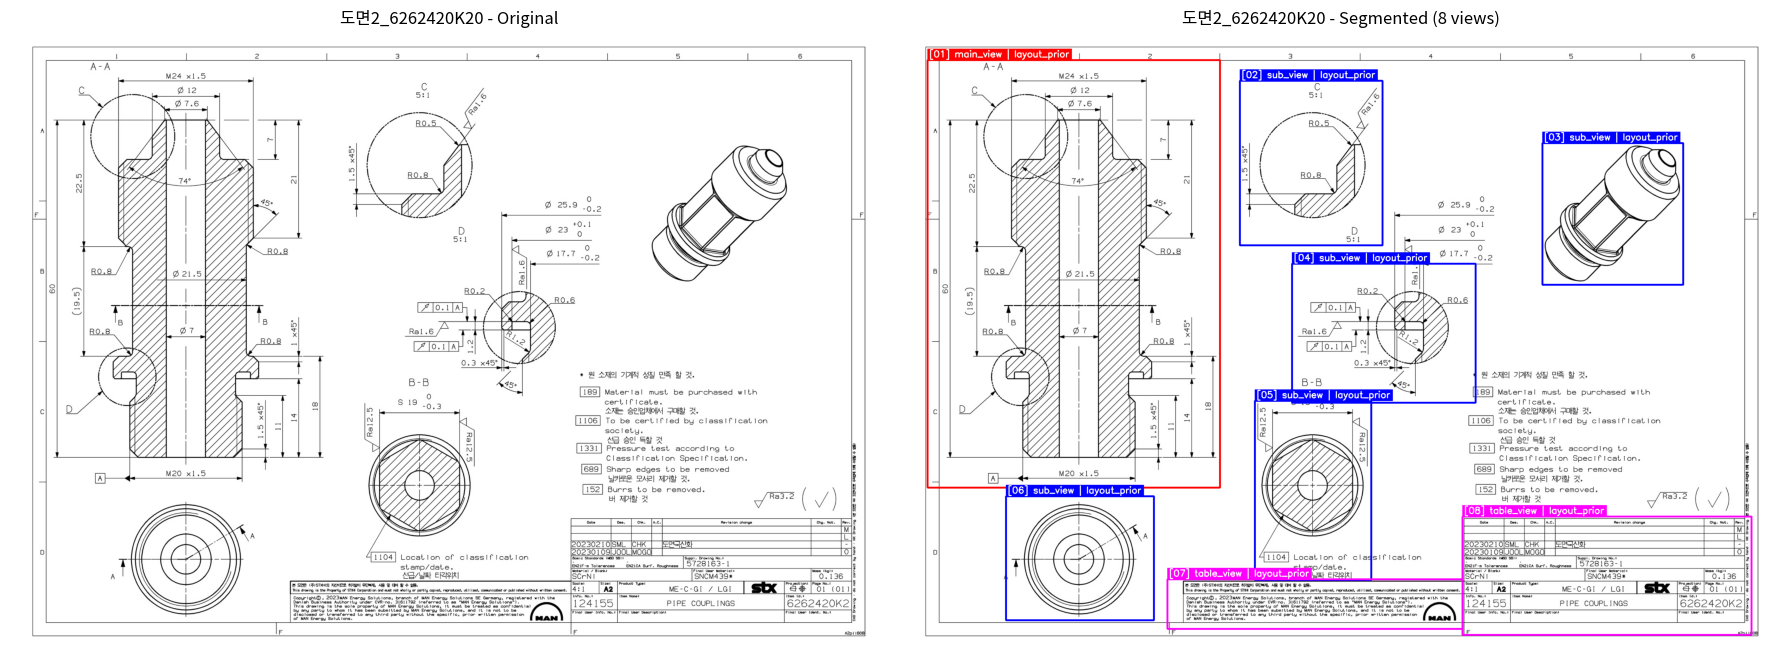

[View Index Titles]
[01] main_view | layout_prior
[02] sub_view | layout_prior
[03] sub_view | layout_prior
[04] sub_view | layout_prior
[05] sub_view | layout_prior
[06] sub_view | layout_prior
[07] table_view | layout_prior
[08] table_view | layout_prior
 -> 성공! 영역이 표시된 최종 이미지가 '../도면2_6262420K20_segmented.jpg'로 저장되었습니다.

[BBox JSON 저장] bbox_exports/도면2_6262420K20_view_bboxes.json


[치수 JSON 저장] bbox_exports/도면2_6262420K20_view_dimensions.json
[치수 추출 요약] views=8, total_dimensions=14
  - view_01 (main_view): 1 items
  - view_02 (sub_view): 7 items
  - view_03 (sub_view): 0 items
  - view_04 (sub_view): 1 items
  - view_05 (sub_view): 4 items
  - view_06 (sub_view): 1 items
  - view_07 (table_view): 0 items
  - view_08 (table_view): 0 items


index,view_id,view_type,source,bbox
1,view_01,main_view,layout_prior,"[65, 77, 844, 1215]"
2,view_02,sub_view,layout_prior,"[897, 132, 1277, 570]"
3,view_03,sub_view,layout_prior,"[1703, 298, 2078, 675]"
4,view_04,sub_view,layout_prior,"[1036, 619, 1525, 989]"
5,view_05,sub_view,layout_prior,"[937, 984, 1247, 1461]"
6,view_06,sub_view,layout_prior,"[274, 1238, 668, 1568]"
7,view_07,table_view,layout_prior,"[704, 1459, 1490, 1591]"
8,view_08,table_view,layout_prior,"[1490, 1292, 2260, 1607]"


index,view_id,view_type,dimension_count,sample dimensions
1,view_01,main_view,1,M24 x1.5
2,view_02,sub_view,7,"1.5, 45°, R0.5, R0.8, ..."
3,view_03,sub_view,0,-
4,view_04,sub_view,1,R0.2
5,view_05,sub_view,4,"5 19 -0.3, Ra12.5, Ra12.5, 1104"
6,view_06,sub_view,1,A
7,view_07,table_view,0,-
8,view_08,table_view,0,-


[../도면2_A1282735700.pdf] PDF를 고해상도 이미지로 변환 중...
 -> '../도면2_A1282735700.jpg' 저장 완료. size=2339x1653
layout prior sub_view CC 확장: crop_03_sub_view.png -> [1055, 620, 1585, 1023]
layout prior sub_view 1차 확장: crop_05_sub_view.png margins={'left': 8, 'top': 7, 'right': 0, 'bottom': 0} -> [236, 1301, 648, 1628]
layout prior sub_view CC 확장: crop_05_sub_view.png -> [228, 1293, 656, 1651]
[../도면2_A1282735700.pdf] layout prior 적용: ../preprocess_out/도면2_A1282735700/manifest.json -> 8 regions | normalized=2400x1693, render=2339x1653, target=2339x1653
[추출된 JSON 데이터]
[
  {
    "view_type": "main_view",
    "box": [
      89,
      41,
      860,
      1217
    ],
    "source": "layout_prior",
    "score": 0.31927938570584763,
    "layout_label": "main_drawing"
  },
  {
    "view_type": "sub_view",
    "box": [
      894,
      127,
      1278,
      568
    ],
    "source": "layout_prior",
    "score": 0.06514668241779878,
    "layout_label": "sub_view"
  },
  {
    "view_type": "sub_view",
    "box

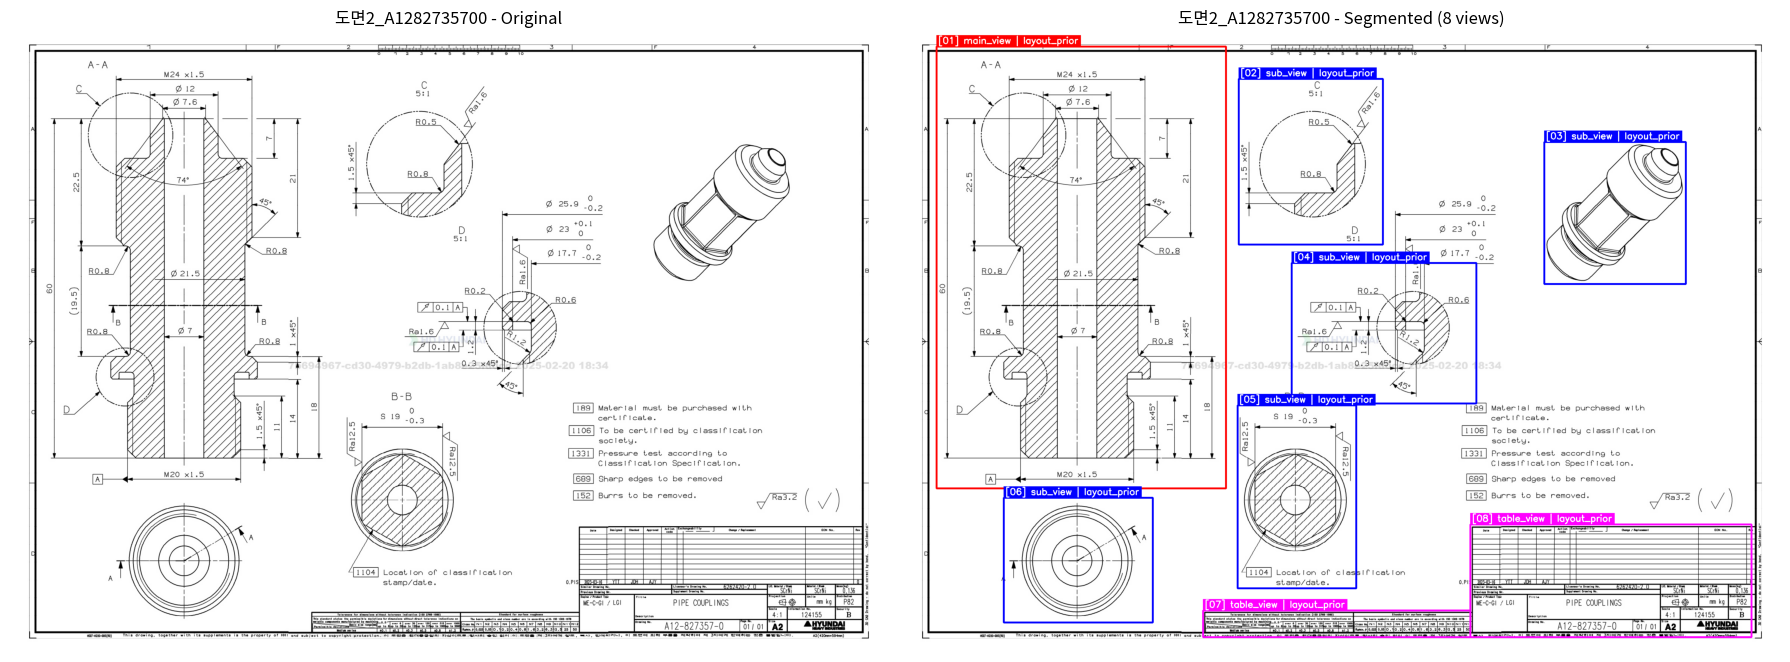

[View Index Titles]
[01] main_view | layout_prior
[02] sub_view | layout_prior
[03] sub_view | layout_prior
[04] sub_view | layout_prior
[05] sub_view | layout_prior
[06] sub_view | layout_prior
[07] table_view | layout_prior
[08] table_view | layout_prior
 -> 성공! 영역이 표시된 최종 이미지가 '../도면2_A1282735700_segmented.jpg'로 저장되었습니다.

[BBox JSON 저장] bbox_exports/도면2_A1282735700_view_bboxes.json
[치수 JSON 저장] bbox_exports/도면2_A1282735700_view_dimensions.json
[치수 추출 요약] views=8, total_dimensions=23
  - view_01 (main_view): 1 items
  - view_02 (sub_view): 9 items
  - view_03 (sub_view): 0 items
  - view_04 (sub_view): 8 items
  - view_05 (sub_view): 4 items
  - view_06 (sub_view): 1 items
  - view_07 (table_view): 0 items
  - view_08 (table_view): 0 items


index,view_id,view_type,source,bbox
1,view_01,main_view,layout_prior,"[89, 41, 860, 1217]"
2,view_02,sub_view,layout_prior,"[894, 127, 1278, 568]"
3,view_03,sub_view,layout_prior,"[1708, 295, 2085, 673]"
4,view_04,sub_view,layout_prior,"[1035, 617, 1527, 991]"
5,view_05,sub_view,layout_prior,"[891, 996, 1207, 1483]"
6,view_06,sub_view,layout_prior,"[268, 1242, 665, 1574]"
7,view_07,table_view,layout_prior,"[799, 1542, 1511, 1613]"
8,view_08,table_view,layout_prior,"[1511, 1313, 2260, 1613]"


index,view_id,view_type,dimension_count,sample dimensions
1,view_01,main_view,1,M24 x1.5
2,view_02,sub_view,9,"1.5, 45°, R0.5, R0.8, ..."
3,view_03,sub_view,0,-
4,view_04,sub_view,8,"R0.2, R0.6, R1.2, Ra1.6, ..."
5,view_05,sub_view,4,"S 19 0 -0.3, Ra12.5, Ra12.5, 1104"
6,view_06,sub_view,1,A
7,view_07,table_view,0,-
8,view_08,table_view,0,-


[비교 JSON 저장] bbox_exports/도면2_6262420K20__vs__도면2_A1282735700_view_dimension_comparison.json


view_id,ref_type,cand_type,ref_dims,cand_dims,exact,strong,partial,unmatched_ref,unmatched_cand,score,status
view_01,main_view,main_view,1,1,1,0,0,0,0,1.0,identical
view_02,sub_view,sub_view,5,7,5,0,0,0,2,0.7143,partial_similarity
view_03,sub_view,sub_view,0,0,0,0,0,0,0,0.0,no_dimensions
view_04,sub_view,sub_view,1,8,1,0,0,0,7,0.125,low_similarity
view_05,sub_view,sub_view,4,4,3,0,0,1,1,0.75,partial_similarity
view_06,sub_view,sub_view,0,0,0,0,0,0,0,0.0,no_dimensions
view_07,table_view,table_view,0,0,0,0,0,0,0,0.0,no_dimensions
view_08,table_view,table_view,0,0,0,0,0,0,0,0.0,no_dimensions


view_id,unmatched_reference,unmatched_candidate
view_01,-,-
view_02,-,"5:1, 5:1"
view_03,-,-
view_04,-,"R0.6, R1.2, Ra1.6, ..."
view_05,5 19 -0.3,S 19 0 -0.3
view_06,-,-
view_07,-,-
view_08,-,-


In [20]:
# ==========================================
# 실행 메인 블록
# ==========================================
pdf_files = [
    resolve_existing_path("도면2_6262420K20.pdf", "../도면2_6262420K20.pdf"),
    resolve_existing_path("도면2_A1282735700.pdf", "../도면2_A1282735700.pdf"),
]

processed_exports = []

for pdf_file in pdf_files:
    if not os.path.exists(pdf_file):
        print(f"경고: {pdf_file} 파일을 찾을 수 없어 건너뜁니다.")
        continue

    jpg_path = convert_pdf_to_image(pdf_file)
    # 각 PDF마다 bbox 추출 -> 시각화 -> 치수 추출 -> 요약 표시를 한 번에 수행합니다.
    views_json = extract_views(jpg_path, pdf_file)

    print("[추출된 JSON 데이터]")
    print(json.dumps(views_json, indent=2, ensure_ascii=False))

    if views_json:
        draw_boxes_on_image(jpg_path, views_json)
        bbox_json_path, dimension_json_path, dimension_payload = export_view_bboxes_and_dimensions(
            pdf_file,
            jpg_path,
            views_json,
        )
        processed_exports.append(
            {
                "pdf_file": pdf_file,
                "bbox_json_path": bbox_json_path,
                "dimension_json_path": dimension_json_path,
            }
        )
        display_export_summary(bbox_json_path, dimension_json_path)
    else:
        print("추출된 view가 없습니다.")

if len(processed_exports) >= 2:
    # 샘플이 2개 이상이면 마지막에 치수 JSON끼리 비교 리포트도 생성합니다.
    comparison_report = compare_dimension_json_files(
        processed_exports[0]["dimension_json_path"],
        processed_exports[1]["dimension_json_path"],
    )
    comparison_json_path = save_comparison_payload(comparison_report, EXPORT_DIR)
    print(f"[비교 JSON 저장] {comparison_json_path}")
    display_comparison_summary(comparison_report, comparison_json_path)
